# 0) NOTEBOOK ENTRY & SETUP

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

DATA_DIR = Path("./../data")
SENSORS = ["Accelerometer", "TotalAcceleration", "Gravity", "Gyroscope"] 

FS = 100
TRIM_S = 5  # seconds removed from start and end

FIG_DIR = Path("./../figures")          # exported folder
FIG_DIR.mkdir(exist_ok=True)

# 1) PRE PROCESSING STAGE
## 1.1 Data set loading

In [2]:
def load_dataset(folder: Path) -> dict:
    """Load one recording folder: metadata, sensor CSVs and the location photo."""
    meta = pd.read_csv(folder / "Metadata.csv").iloc[0].to_dict()

    sensors = {}
    for name in SENSORS:
        csv = folder / f"{name}.csv"
        if csv.exists():
            df = pd.read_csv(csv)
            df["t"] = df["seconds_elapsed"]
            sensors[name] = df

    photos = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png")))
    photo = None
    if photos:
        photo = ImageOps.exif_transpose(Image.open(photos[0]))
        photo.thumbnail((1200, 1200))   #to keep notebook light

    start = pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True).tz_convert(meta["recording timezone"])
    return {
        "name": folder.name,
        "folder": folder,
        "meta": meta,
        "start": start,
        "sensors": sensors,
        "photo": photo,
        "photo_name": photos[0].name if photos else None,
    }

datasets = [load_dataset(d) for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]
print(f"Loaded {len(datasets)} datasets:", [d["name"] for d in datasets])

Loaded 26 datasets: ['P01_B01', 'P01_B02', 'P01_B03', 'P01_B04', 'P01_B05', 'P01_B06', 'P01_S01', 'P01_S02', 'P01_S03', 'P01_S04', 'P02_B01', 'P02_B02', 'P02_B03', 'P02_B04', 'P02_S01', 'P02_S02', 'P02_S03', 'P02_S04', 'P03_B01', 'P03_B02', 'P03_B03', 'P03_B04', 'P03_S01', 'P03_S02', 'P03_S03', 'P03_S04']


## 1.2 Data Inventory: 

Each row row represents each measurement.

In [3]:
LABELS = {"B": "bumpy", "S": "smooth"}

def list_recordings(data_dir: Path) -> pd.DataFrame:
    """One row per recording folder named Pxx_Byy / Pxx_Syy: id, participant, label, path, metadata."""
    rows = []
    for rec in sorted(data_dir.iterdir()):                # data/P01_B03
        if not (rec.is_dir() and (rec / "Metadata.csv").exists()):
            continue
        participant, ride = rec.name.split("_")
        meta = pd.read_csv(rec / "Metadata.csv").iloc[0]
        rows.append({
            "recording_id": rec.name,
            "participant": participant,
            "label": LABELS[ride[0]],
            "path": rec,
            "device": meta["device name"],
            "start_time": pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True)
                            .tz_convert(meta["recording timezone"]),
        })
    return pd.DataFrame(rows)


recordings = list_recordings(DATA_DIR)
# print(f"{len(recordings)} recordings")
# print(recordings.groupby(["participant", "label"]).size())
recordings

,recording_id,participant,label,path,device,start_time
0,P01_B01,P01,bumpy,..\data\P01_B01,SM-G780G,2026-09-22 19:08:25.248000+02:00
1,P01_B02,P01,bumpy,..\data\P01_B02,SM-G780G,2026-09-22 19:10:13.562000+02:00
2,P01_B03,P01,bumpy,..\data\P01_B03,SM-G780G,2026-09-22 19:18:12.036000+02:00
3,P01_B04,P01,bumpy,..\data\P01_B04,SM-G780G,2026-09-22 19:13:04.689000+02:00
4,P01_B05,P01,bumpy,..\data\P01_B05,SM-G780G,2026-09-22 19:05:49.591000+02:00
5,P01_B06,P01,bumpy,..\data\P01_B06,SM-G780G,2026-09-22 19:04:51.242000+02:00
6,P01_S01,P01,smooth,..\data\P01_S01,SM-G780G,2026-09-22 19:16:26.646000+02:00
7,P01_S02,P01,smooth,..\data\P01_S02,SM-G780G,2026-09-22 19:15:02.242000+02:00
8,P01_S03,P01,smooth,..\data\P01_S03,SM-G780G,2026-09-22 19:07:06.701000+02:00
9,P01_S04,P01,smooth,..\data\P01_S04,SM-G780G,2026-09-22 19:11:19.655000+02:00


## 1.3 Sampling Consistency analysis

In [4]:
PREFIX = {"Accelerometer": "acc", "TotalAcceleration": "tacc", "Gravity": "grav", "Gyroscope": "gyro"}
TOL_S = 0.005   # max timestamp distance between samples across sensors (= half a sample at 100 Hz)

def load_recording(rec_path: Path, sensors=SENSORS) -> pd.DataFrame:
    """Join the sensor CSVs sample-by-sample on their timestamps. No resampling."""
    out = None
    for name in sensors:
        if not (rec_path / f"{name}.csv").exists():
            continue
        df = pd.read_csv(rec_path / f"{name}.csv")[["seconds_elapsed", "x", "y", "z"]].sort_values("seconds_elapsed")
        df.columns = ["t"] + [f"{PREFIX[name]}_{a}" for a in "xyz"]
        out = df if out is None else pd.merge_asof(out, df, on="t", direction="nearest", tolerance=TOL_S)
    out = out.dropna().reset_index(drop=True)
    if "tacc_x" not in out:                                     
        for a in "xyz":
            out[f"tacc_{a}"] = out[f"acc_{a}"] + out[f"grav_{a}"]
    return out

# load everything once: keep recording_id / participant / label on every row
data = {}
for r in recordings.itertuples():
    df = load_recording(r.path)
    df["recording_id"] = r.recording_id
    df["participant"] = r.participant
    df["label"] = r.label
    data[r.recording_id] = df

n = sum(len(d) for d in data.values())
print(f"Loaded {len(data)} recordings, {n} samples at {FS} Hz ({n / FS / 60:.1f} min)")

pd.DataFrame(
    {k: {"samples": len(v), 
         "median_dt_ms": 1000 * np.median(np.diff(v["t"])), 
         "max_dt_ms": 1000 * np.diff(v["t"]).max()} 
     for k, v in data.items()
    }).T.round(2)

Loaded 26 recordings, 187009 samples at 100 Hz (31.2 min)


,samples,median_dt_ms,max_dt_ms
P01_B01,6748.0,10.00,10.00
P01_B02,4248.0,10.00,10.00
P01_B03,4483.0,10.00,10.00
P01_B04,5102.0,10.00,10.00
P01_B05,5609.0,10.00,10.00
P01_B06,3559.0,10.00,10.00
P01_S01,3964.0,10.00,10.00
P01_S02,5098.0,10.00,10.00
P01_S03,6062.0,10.00,10.00
P01_S04,7674.0,10.00,10.00


## 1.4 Trim

From initial time plots, and discussions it has been established that the first/last 5 seconds are most of the times for putting away the phone.

In [5]:
def trim(df: pd.DataFrame, trim_s: float = TRIM_S) -> pd.DataFrame:
    t0, t1 = df["t"].iloc[0] + trim_s, df["t"].iloc[-1] - trim_s
    return df[(df["t"] >= t0) & (df["t"] <= t1)].reset_index(drop=True)

trimmed = {k: trim(v) for k, v in data.items()}
durations = pd.DataFrame({
    "raw_s": {k: v["t"].iloc[-1] - v["t"].iloc[0] for k, v in data.items()},
    "trimmed_s": {k: v["t"].iloc[-1] - v["t"].iloc[0] for k, v in trimmed.items()},
}).round(1)

print(f"Shortest trimmed recording: {durations['trimmed_s'].min()} s ({durations['trimmed_s'].idxmin()})")
durations.T

Shortest trimmed recording: 25.6 s (P01_B06)


,P01_B01,P01_B02,P01_B03,P01_B04,P01_B05,P01_B06,P01_S01,P01_S02,P01_S03,P01_S04,...,P02_S03,P02_S04,P03_B01,P03_B02,P03_B03,P03_B04,P03_S01,P03_S02,P03_S03,P03_S04
raw_s,67.5,42.5,44.8,51.0,56.1,35.6,39.6,51.0,60.6,76.7,...,79.9,87.5,124.5,112.1,63.7,63.0,86.4,79.1,62.1,66.4
trimmed_s,57.5,32.5,34.8,41.0,46.1,25.6,29.6,41.0,50.6,66.7,...,69.9,77.4,114.5,102.1,53.7,53.0,76.4,69.1,52.1,56.3


## 1.5 Dataset statistics

One row per recording (after trimming): how much data per class, per participant, per device, and how long the rides are.

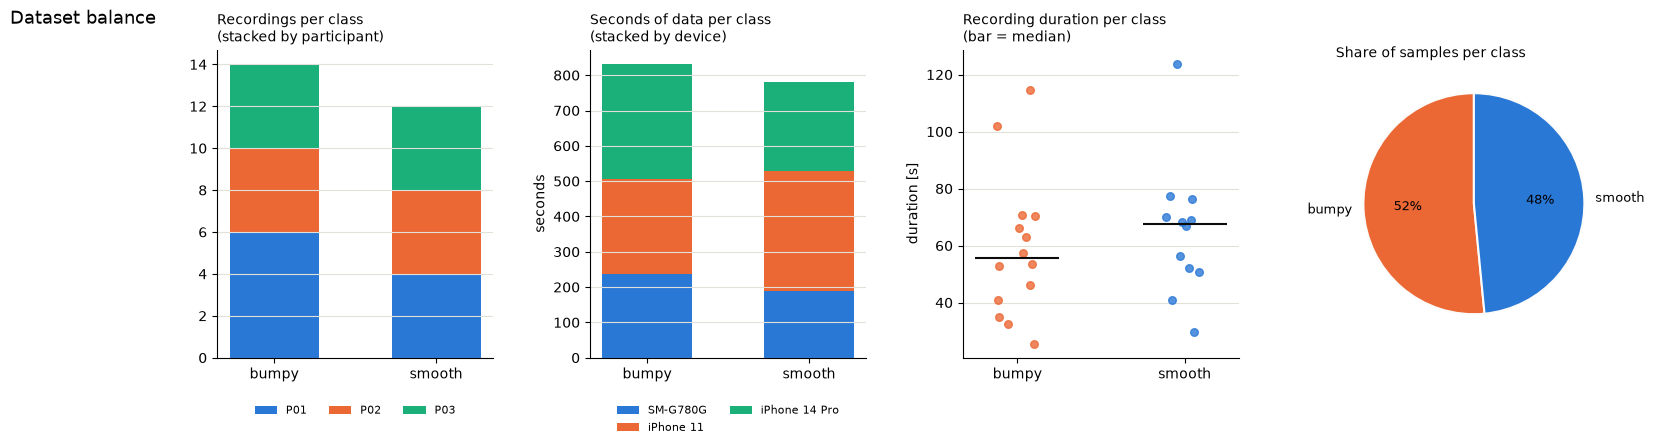

26 recordings, 26.9 min, 161026 samples


recordings  seconds
participant class                      
P01         bumpy            6    237.0
            smooth           4    188.0
P02         bumpy            4    270.0
            smooth           4    340.0
P03         bumpy            4    323.0
            smooth           4    254.0

In [6]:
CLASSES = ["bumpy", "smooth"]
UNITS = {"acc": "m/s^2 (gravity removed)", "tacc": "m/s^2", "grav": "m/s^2", "gyro": "rad/s"}

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]
AXIS_COLOR = dict(zip("xyz", PALETTE))
CLASS_COLOR = {"bumpy": "#eb6834", "smooth": "#2a78d6"}

plt.rcParams.update({"axes.grid": True, "grid.color": "#e1e0d9", "axes.spines.top": False, "axes.spines.right": False,
                     "lines.linewidth": 1.0, "figure.dpi": 100})

summary = pd.DataFrame([{
    "recording_id": k, "class": v["label"].iloc[0], "participant": v["participant"].iloc[0],
    "device": recordings.set_index("recording_id").loc[k, "device"],
    "duration_s": v["t"].iloc[-1] - v["t"].iloc[0], "samples": len(v),
} for k, v in trimmed.items()])

fig, axes = plt.subplots(1, 4, figsize=(18, 4), gridspec_kw={"wspace": 0.35})

# (a) recordings per class, stacked by participant
ct = pd.crosstab(summary["class"], summary["participant"]).reindex(CLASSES)
part_colors = {p: PALETTE[i % len(PALETTE)] for i, p in enumerate(sorted(summary["participant"].unique()))}
bottom = np.zeros(len(ct))

for p in ct.columns:
    axes[0].bar(ct.index, ct[p], bottom=bottom, color=part_colors[p], label=p, width=0.55)
    bottom += ct[p].values
    
axes[0].set_title("Recordings per class\n(stacked by participant)", loc="left", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
axes[0].grid(axis="x", visible=False)

# (b) seconds per class, stacked by device
ct = pd.crosstab(summary["class"], summary["device"], values=summary["duration_s"], aggfunc="sum").fillna(0).reindex(CLASSES)
dev_colors = {dv: PALETTE[i % len(PALETTE)] for i, dv in enumerate(sorted(summary["device"].unique()))}
bottom = np.zeros(len(ct))

for dv in ct.columns:
    axes[1].bar(ct.index, ct[dv], bottom=bottom, color=dev_colors[dv], label=dv, width=0.55)
    bottom += ct[dv].values
    
axes[1].set_title("Seconds of data per class\n(stacked by device)", loc="left", fontsize=10)
axes[1].set_ylabel("seconds")
axes[1].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
axes[1].grid(axis="x", visible=False)

# (c) duration distribution per class
rng = np.random.default_rng(0)

for i, cls in enumerate(CLASSES):
    dur = summary.loc[summary["class"] == cls, "duration_s"]
    axes[2].scatter(np.full(len(dur), i) + rng.uniform(-0.12, 0.12, len(dur)), dur,
                    color=CLASS_COLOR[cls], alpha=0.8, s=30, zorder=3)
    axes[2].hlines(dur.median(), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.5, zorder=4)
    
axes[2].set_xticks(range(len(CLASSES)), CLASSES)
axes[2].set_ylabel("duration [s]")
axes[2].set_title("Recording duration per class\n(bar = median)", loc="left", fontsize=10)
axes[2].grid(axis="x", visible=False)

# (d) share of samples per class
samples = summary.groupby("class")["samples"].sum().reindex(CLASSES)

axes[3].pie(samples, labels=samples.index, colors=[CLASS_COLOR[c] for c in samples.index],
            autopct="%1.0f%%", startangle=90, wedgeprops={"linewidth": 1.5, "edgecolor": "#fcfcfb"},
            textprops={"fontsize": 9})

axes[3].set_title("Share of samples per class", loc="left", fontsize=10)
axes[3].grid(False)

fig.suptitle("Dataset balance", fontsize=13, x=0.01, ha="left")
fig.savefig(FIG_DIR / "dataset_balance.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"{len(summary)} recordings, {summary['duration_s'].sum() / 60:.1f} min, {summary['samples'].sum()} samples")
summary.groupby(["participant", "class"]).agg(recordings=("recording_id", "count"), seconds=("duration_s", "sum")).round(0)

## 1.6 Time Series Visualization

Plot selected/typed measurement: one subplot per sensor, x/y/z in fixed colours.

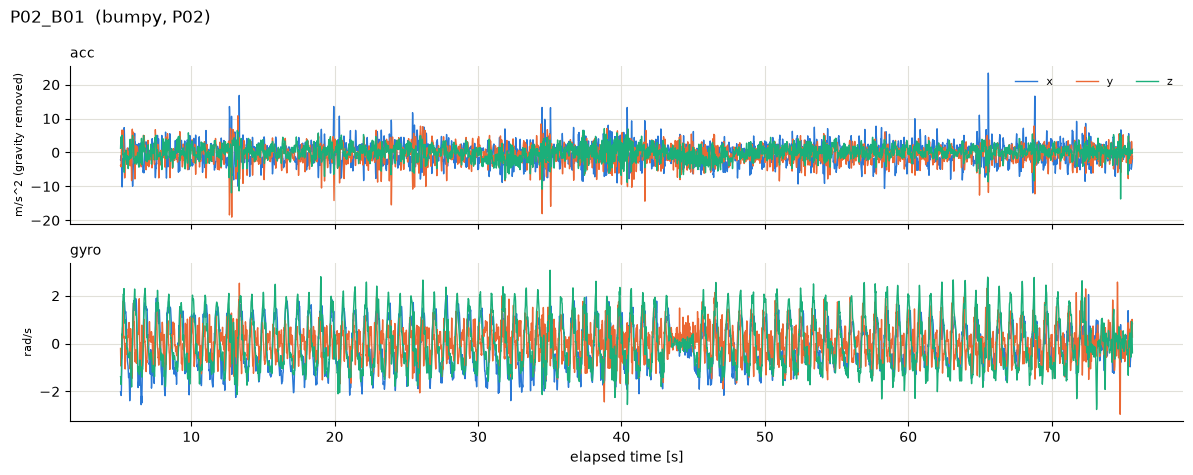

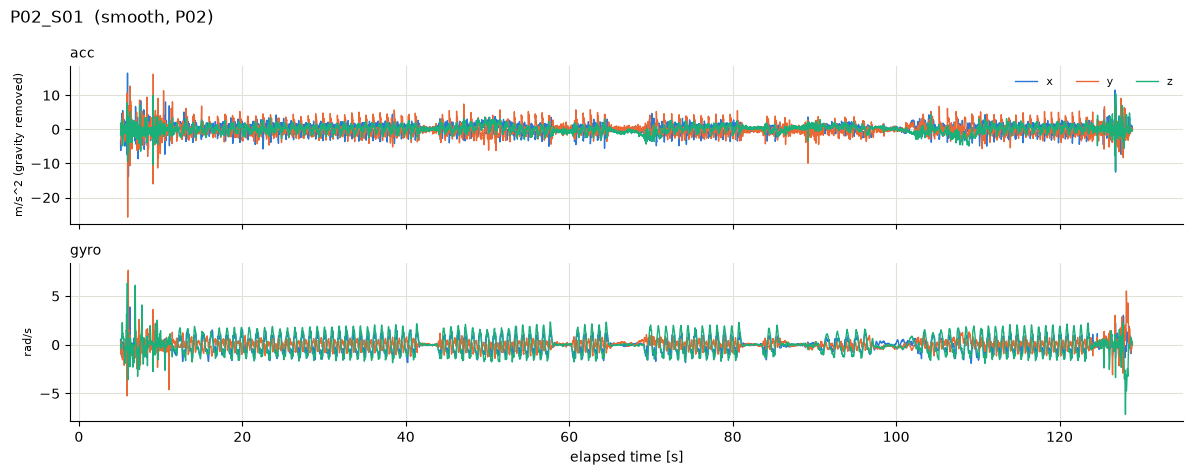

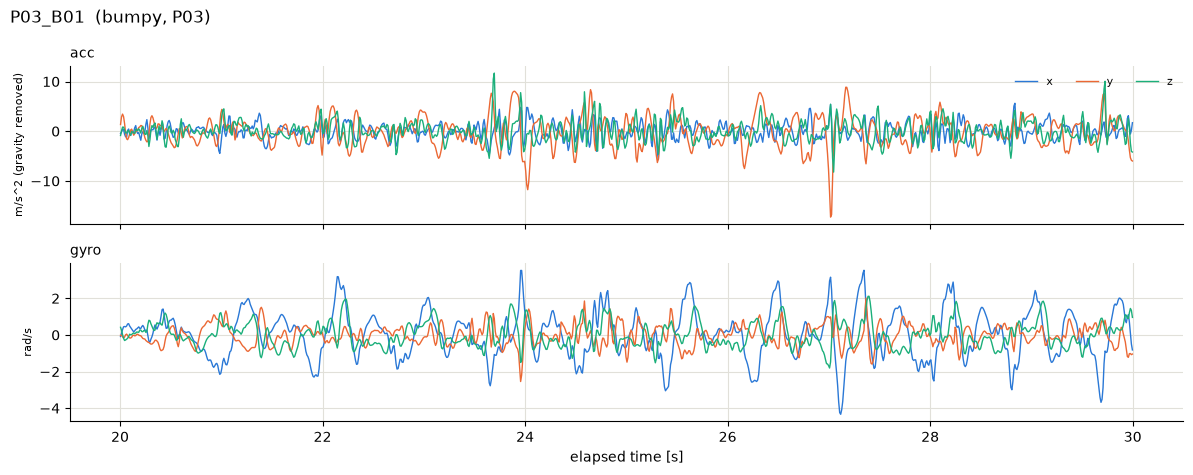

In [7]:
def plot_recording(df: pd.DataFrame, sensors=("acc", "gyro"), t_start=None, t_end=None, save=False):
    rec = df["recording_id"].iloc[0]
    if t_start is not None or t_end is not None:
        df = df[(df["t"] >= (t_start or -np.inf)) & (df["t"] <= (t_end or np.inf))]

    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 2.4 * len(sensors)), sharex=True, squeeze=False)
    for ax, s in zip(axes[:, 0], sensors):
        for a in "xyz":
            ax.plot(df["t"], df[f"{s}_{a}"], color=AXIS_COLOR[a], label=a)
        ax.set_ylabel(UNITS[s], fontsize=8)
        ax.set_title(s, loc="left", fontsize=10)
    axes[0, 0].legend(loc="upper right", ncol=3, frameon=False, fontsize=8)
    axes[-1, 0].set_xlabel("elapsed time [s]")
    fig.suptitle(f"{rec}  ({df['label'].iloc[0]}, {df['participant'].iloc[0]})", x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_DIR / f"{rec}.png", bbox_inches="tight")
    plt.show()

plot_recording(trimmed["P02_B01"])
plot_recording(trimmed["P02_S01"])
plot_recording(trimmed["P03_B01"], t_start=20, t_end=30)   # zoom on 10 s

## 1.7 Normalization 

The phone can be mounted differently in every ride, since we did not explicitly specify in the data collection protocol precisely. Therefore x,y,z have different interpretation per recording, therefore we normalize (or convert) into a orientation invariant equivalent. 

Consider: 
- `acc_mag`   = abs(acc)
- `acc_vert`  = acc projected on the gravity direction (up/down: the road-roughness signal)
- `acc_horiz` = the remaining horizontal part
- `gyro_mag`  = abs(gyro)
- `tacc_mag`  = abs(TotalAcceleration), {gravity + vibration in one number: after mean removal ~ `acc_vert`}



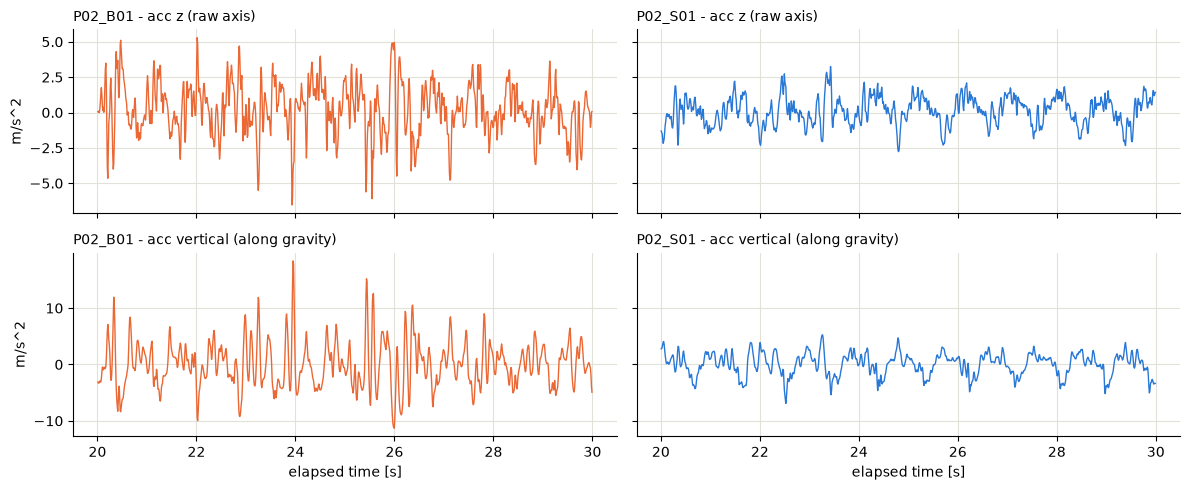

In [8]:
def add_channels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    g = df[["grav_x", "grav_y", "grav_z"]].to_numpy()
    g = g / np.linalg.norm(g, axis=1, keepdims=True)      # Euclidean norm: unit "down" vector per sample
    
    a = df[["acc_x", "acc_y", "acc_z"]].to_numpy()
    df["acc_mag"] = np.linalg.norm(a, axis=1)             # Euclidean norm: Total intensity of movement 
    
    # Vertical acceleration isolation
    df["acc_vertical"] = (a * g).sum(axis=1)              # Dot-product: projection
    
    # Horizontal acceleration isolation
    df["acc_horizontal"] = np.sqrt(np.clip(df["acc_mag"] ** 2 - df["acc_vertical"] ** 2, 0, None)) # Pythagoras theorem
    
    df["gyro_mag"] = np.linalg.norm(df[["gyro_x", "gyro_y", "gyro_z"]].to_numpy(), axis=1)
    df["tacc_mag"] = np.linalg.norm(df[["tacc_x", "tacc_y", "tacc_z"]].to_numpy(), axis=1)
    return df

trimmed = {k: add_channels(v) for k, v in trimmed.items()}

# raw axis vs. orientation-free channel: one bumpy and one smooth ride
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex="col", sharey="row")

for col, rec in enumerate(["P02_B01", "P02_S01"]):
    d = trimmed[rec]; d = d[(d["t"] >= 20) & (d["t"] <= 30)]
    c = CLASS_COLOR[d["label"].iloc[0]]
    
    axes[0, col].plot(d["t"], d["acc_z"], color=c);    axes[0, col].set_title(f"{rec} - acc z (raw axis)", loc="left", fontsize=10)
    axes[1, col].plot(d["t"], d["acc_vertical"], color=c); axes[1, col].set_title(f"{rec} - acc vertical (along gravity)", loc="left", fontsize=10)
    axes[1, col].set_xlabel("elapsed time [s]")
    
axes[0, 0].set_ylabel("m/s^2"); axes[1, 0].set_ylabel("m/s^2")
fig.tight_layout(); plt.show()

## 1.8 Frequency Filtering

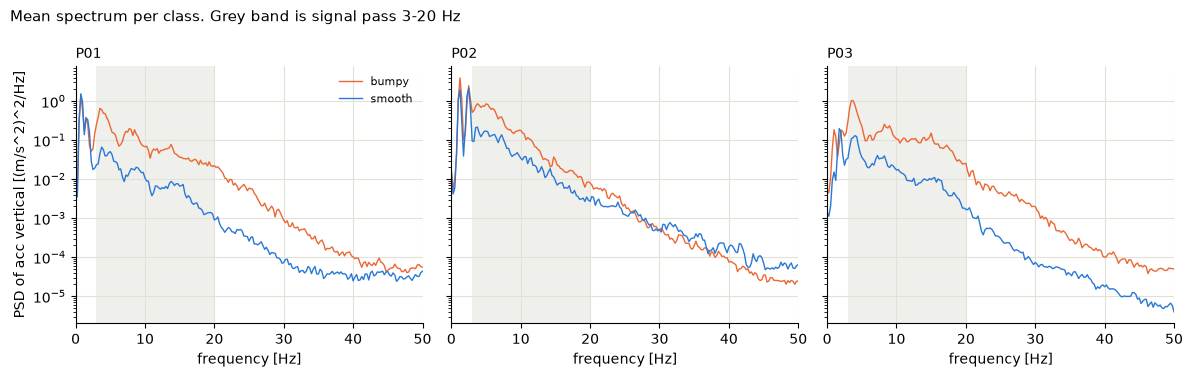

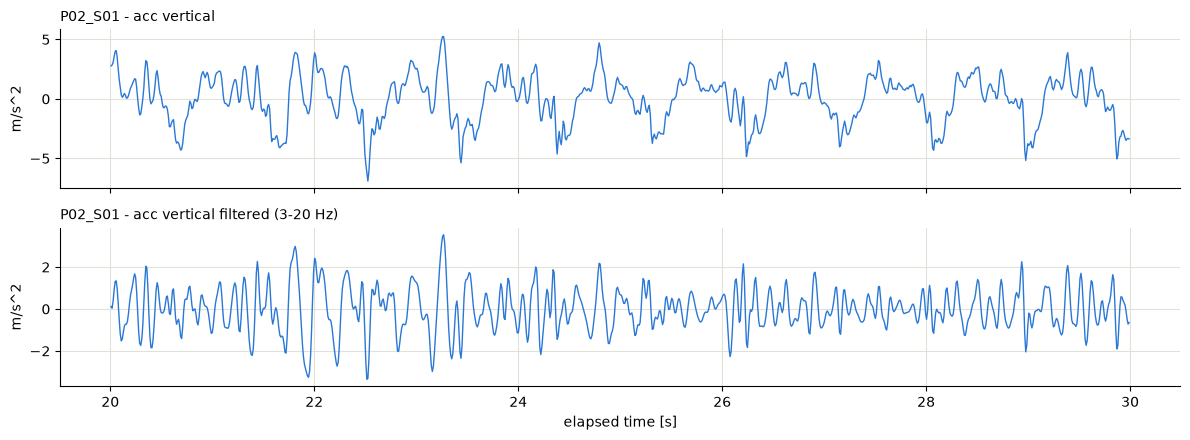

In [13]:
BAND = (3.0, 20.0) 

def bandpass(x: np.ndarray, lo: float = BAND[0], hi: float = BAND[1], fs: int = FS) -> np.ndarray:
    """Zero-phase FFT band-pass: keep only bins with lo <= f <= hi."""
    X = np.fft.rfft(x - x.mean())
    f = np.fft.rfftfreq(len(x), 1 / fs)
    X[(f < lo) | (f > hi)] = 0
    return np.fft.irfft(X, len(x))

def mean_spectrum(x: np.ndarray, fs: int = FS, n: int = 4 * FS):
    """Averaged periodogram over n-sample chunks (Hann window)."""
    x = x[: len(x) // n * n].reshape(-1, n)
    w = np.hanning(n)
    x = (x - x.mean(axis=1, keepdims=True)) * w
    psd = (np.abs(np.fft.rfft(x, axis=1)) ** 2).mean(axis=0) / (fs * (w ** 2).sum())
    return np.fft.rfftfreq(n, 1 / fs), psd

for v in trimmed.values():
    v["acc_vertical_filtered"] = bandpass(v["acc_vertical"].to_numpy())

# where does the class difference live? mean spectrum of acc_vert per class and participant
participants = sorted(recordings["participant"].unique())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for ax, p in zip(axes, participants):
    for label in CLASSES:
        recs = [k for k, v in trimmed.items() if v["participant"].iloc[0] == p and v["label"].iloc[0] == label]
        f, psd = zip(*(mean_spectrum(trimmed[k]["acc_vertical"].to_numpy()) for k in recs))
        ax.semilogy(f[0], np.mean(psd, axis=0), color=CLASS_COLOR[label], label=label)
    ax.axvspan(*BAND, color="#e1e0d9", alpha=0.5, lw=0)
    ax.set_title(p, loc="left", fontsize=10); ax.set_xlabel("frequency [Hz]"); ax.set_xlim(0, FS / 2)
    
axes[0].set_ylabel("PSD of acc vertical [(m/s^2)^2/Hz]"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Mean spectrum per class. Grey band is signal pass {BAND[0]:.0f}-{BAND[1]:.0f} Hz", x=0.01, ha="left", fontsize=11)
fig.tight_layout(); plt.show()

# before / after in the time domain
fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
d = trimmed["P02_S01"]; d = d[(d["t"] >= 20) & (d["t"] <= 30)]

axes[0].plot(d["t"], d["acc_vertical"], color=CLASS_COLOR["smooth"]);    axes[0].set_title("P02_S01 - acc vertical", loc="left", fontsize=10)
axes[1].plot(d["t"], d["acc_vertical_filtered"], color=CLASS_COLOR["smooth"]); axes[1].set_title(f"P02_S01 - acc vertical filtered ({BAND[0]:.0f}-{BAND[1]:.0f} Hz)", loc="left", fontsize=10)
axes[1].set_xlabel("elapsed time [s]"); axes[0].set_ylabel("m/s^2"); axes[1].set_ylabel("m/s^2")
fig.tight_layout(); plt.show()

## 1.9 Windowing

We observe that road-roughness is stationary over a few seconds, so each recording is cut into **4 s windows with a 2 s step** (50 % overlap).
Windows are defined by sample count (400 samples at 100 Hz): the timestamps are regular enough for that

Output: `X` of shape `(n_windows, 400, n_channels)` and `windows` (one row of metadata per window). `recording_id` and
`participant` stay attached to every window so the split can be made by ride / by participant later.

(Smoothing such as a moving average is *not* applied: Due to road texture we want to maintain)

X: (768, 400, 5)  (windows, samples, channels=['acc_vertical', 'acc_vertical_filtered', 'acc_horizontal', 'gyro_mag', 'tacc_mag'])


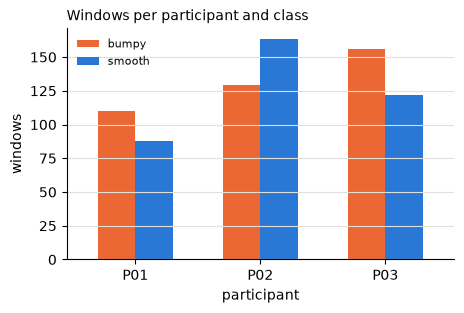

label,bumpy,smooth
participant,,
P01,110,88
P02,129,163
P03,156,122


In [10]:
WIN_S, STEP_S = 4, 2
WIN, STEP = WIN_S * FS, STEP_S * FS
CHANNELS = ["acc_vertical", "acc_vertical_filtered", "acc_horizontal", "gyro_mag", "tacc_mag"]

def make_windows(df: pd.DataFrame, win: int = WIN, step: int = STEP, channels=CHANNELS):
    """Return (array of shape (n, win, len(channels)), list of metadata dicts)."""
    arr = df[channels].to_numpy(np.float32)
    starts = range(0, len(df) - win + 1, step)
    
    X = np.stack([arr[s:s + win] for s in starts]) if len(df) >= win else np.empty((0, win, len(channels)), np.float32)
    
    meta = [{"window_id": f"{df['recording_id'].iloc[0]}_W{i:03d}", "recording_id": df["recording_id"].iloc[0],
             "participant": df["participant"].iloc[0], "label": df["label"].iloc[0], "t_start": df["t"].iloc[s]}
            for i, s in enumerate(starts)]
    return X, meta

Xs, metas = zip(*(make_windows(v) for v in trimmed.values()))
X = np.concatenate(Xs)
windows = pd.DataFrame([m for mm in metas for m in mm])
print(f"X: {X.shape}  (windows, samples, channels={CHANNELS})")

counts = windows.groupby(["participant", "label"]).size().unstack().reindex(columns=CLASSES)
ax = counts.plot.bar(color=[CLASS_COLOR[c] for c in CLASSES], width=0.6, figsize=(5, 3), rot=0)
ax.set_ylabel("windows"); ax.set_title("Windows per participant and class", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="x", visible=False); plt.show()

counts

## 1.10 Window Statistics

Statistical computations: 
- vert_std: Standard deviation of vertical acceleration (measures overall movement intensity).
- vert_iqr: Interquartile range of vertical acceleration (spread of the middle 50% of the data, robust to outliers).
- vert_p2p: Peak-to-peak amplitude (maximum minus minimum value).
- vert_p95abs: 95th percentile of the absolute acceleration (captures maximum intensity while ignoring extreme anomalies).
- vert_madiff: Mean absolute difference of consecutive samples (measures signal jerkiness or high-frequency changes).
- gyro_std: Variance in rotational speed.
- gyro_mean: Average rotational speed.

In [11]:
def basic_stats(w: np.ndarray) -> dict:
    """w: one window, shape (samples, channels) in CHANNELS order."""
    v = w[:, CHANNELS.index("acc_vertical_filtered")]
    g = w[:, CHANNELS.index("gyro_mag")]
    
    return {
        "vert_std": v.std(), "vert_iqr": np.subtract(*np.percentile(v, [75, 25])), "vert_p2p": np.ptp(v),
        "vert_p95abs": np.percentile(np.abs(v), 95), "vert_madiff": np.abs(np.diff(v)).mean(),
        "gyro_std": g.std(), "gyro_mean": g.mean(),
    }

stats = pd.concat([windows, pd.DataFrame([basic_stats(w) for w in X])], axis=1)
STAT_COLS = [c for c in stats.columns if c not in windows.columns]

print("per class (mean over windows):")
display(stats.groupby("label")[STAT_COLS].mean().reindex(CLASSES).round(3))

print("per participant and class:")
stats.groupby(["participant", "label"])[STAT_COLS].agg(["mean", "std"]).round(3)

per class (mean over windows):


,vert_std,vert_iqr,vert_p2p,vert_p95abs,vert_madiff,gyro_std,gyro_mean
label,,,,,,,
bumpy,2.372,2.918,15.392,4.705,0.869,0.575,1.187
smooth,0.940,1.115,6.348,1.903,0.348,0.579,1.176


per participant and class:


vert_std        vert_iqr        vert_p2p         \
                       mean    std     mean    std     mean    std   
participant label                                                    
P01         bumpy     1.986  0.451    2.568  0.523   11.956  3.539   
            smooth    0.662  0.178    0.803  0.157    4.462  1.917   
P02         bumpy     2.785  0.646    3.331  0.615   18.614  6.643   
            smooth    1.190  0.456    1.398  0.462    8.053  4.192   
P03         bumpy     2.303  0.657    2.823  0.857   15.151  5.196   
            smooth    0.807  0.340    0.961  0.318    5.429  2.860   

                   vert_p95abs        vert_madiff        gyro_std         \
                          mean    std        mean    std     mean    std   
participant label                                                          
P01         bumpy        3.905  0.963       0.783  0.133    0.541  0.047   
            smooth       1.334  0.411       0.255  0.055    0.565  0.054   
P02         bumpy        5.527  1.416       0.892  0.179    0.646  0.041   
            smooth       2.407  0.963       0.417  0.139    0.743  0.380   
P03         bumpy        4.589  1.360       0.910  0.268    0.540  0.265   
            smooth       1.639  0.768       0.322  0.110    0.370  0.333   

                   gyro_mean         
                        mean    std  
participant label                    
P01         bumpy      1.157  0.100  
            smooth     1.153  0.101  
P02         bumpy      1.460  0.138  
            smooth     1.505  0.633  
P03         bumpy      0.981  0.346  
            smooth     0.753  0.657

## 1.11 Interim Backup of Pre-Processed Data

Everything downstream (features, models) starts from these two files later so it is useful to backup at this stage.

In [12]:
PROC_DIR = Path("./../artifacts")
PROC_DIR.mkdir(exist_ok=True)

np.savez_compressed(PROC_DIR / "windows.npz", X=X, channels=np.array(CHANNELS), fs=FS, win_s=WIN_S, step_s=STEP_S, band=np.array(BAND))
windows.to_csv(PROC_DIR / "windows_meta.csv", index=False)

print(f"saved {X.shape} -> {PROC_DIR / 'windows.npz'}  ({(PROC_DIR / 'windows.npz').stat().st_size / 1e6:.1f} MB)")
print(f"saved {len(windows)} rows -> {PROC_DIR / 'windows_meta.csv'}")

saved (768, 400, 5) -> ..\artifacts\windows.npz  (3.0 MB)
saved 768 rows -> ..\artifacts\windows_meta.csv
